In [8]:
%%bash
pip install matplotlib pandas pillow


In [86]:
#Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, MaxNLocator
import numpy as np

In [58]:
def read_orca(file_path):
    # Read CSV with multi-level header
    physical_properties = pd.read_csv(
        file_path,
        skiprows=4,
        header=[0, 1]
    )

    # Convert MultiIndex columns to dataframe
    cols = physical_properties.columns.to_frame()

    # Forward-fill blank top-level headers
    cols[0] = cols[0].replace(
        r'^\s*$',
        pd.NA,
        regex=True
    ).ffill()

    # Rebuild column names
    physical_properties.columns = [
        f"{a}_{b}"
        for a, b in cols.to_numpy()
    ]

    # Clean names
    physical_properties.columns = (
        pd.Index(physical_properties.columns)
        .str.replace(r"[^\w]", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )

    physical_properties = physical_properties.rename(columns={
        "Section_Unnamed_2_level_1": "Section",
        "Time_Stamp_Unnamed_4_level_1": "Time_Stamp",
        "Unnamed_231_level_0_Beam_2": "XRF_Total_Counts_Beam_2"
    })

    # Replace empty strings and whitespace-only strings with NaN
    # before numeric coercion — ORCA exports empty strings rather
    # than true nulls for missing values, which causes them to plot as zero
    physical_properties = physical_properties.replace(r'^\s*$', np.nan, regex=True)
    physical_properties = physical_properties.replace('\xa0', np.nan, regex=True)

    numeric_cols = physical_properties.columns.drop(["Section", "Time_Stamp"])
    for col in numeric_cols:
        physical_properties[col] = pd.to_numeric(physical_properties[col], errors="coerce")

    return physical_properties

In [62]:
#READ IN THE LAB RESULTS

def read_lab_results(file_path):
    # -----------------------------
    # Read raw CSV (no MultiIndex)
    # -----------------------------
    raw = pd.read_csv(
        file_path,
        skiprows=2,   # skip BOTH header rows cleanly
        header=None
    )

    # -----------------------------
    # Manually assign correct column names
    # -----------------------------
    raw.columns = [
        "Sample",
        "Start_Depth_mm",
        "End_Depth_mm",
        "Depth_Midpoint_mm",
        "Particle_Weight",
        "CN_Weight",
        "Event_Notes",
        "Epoch",
        "Grain_Size_Mean",
        "Grain_Size_Sorting",
        "Grain_Size_Skewness",
        "Grain_Size_Kurtosis",
        "CN_Ratio"
    ]

    lab_results = raw

    # -----------------------------
    # Depth conversion
    # -----------------------------
    lab_results["Depth_Unit"] = "mm"
    lab_results["Depth_Converted_To_cm"] = True

    lab_results["Start_Depth_cm"] = lab_results["Start_Depth_mm"] / 10
    lab_results["End_Depth_cm"] = lab_results["End_Depth_mm"] / 10
    lab_results["Depth_Midpoint_cm"] = lab_results["Depth_Midpoint_mm"] / 10

    # -----------------------------
    
    # Force numeric columns
    # -----------------------------
    numeric_cols = [
        "Start_Depth_mm",
        "End_Depth_mm",
        "Depth_Midpoint_mm",
        "Particle_Weight",
        "CN_Weight",
        "Grain_Size_Mean",
        "Grain_Size_Sorting",
        "Grain_Size_Skewness",
        "Grain_Size_Kurtosis",
        "CN_Ratio"
    ]

    for col in numeric_cols:
        lab_results[col] = pd.to_numeric(lab_results[col], errors="coerce")

    return lab_results

In [143]:
def plot_core(core_name, core_image_path, properties_df, lab_results_df, max_depth, events=()):
    """
    Plot a sediment core with proxy records.

    Parameters
    ----------
    core_image_path : str — path to the core photograph
    properties_df   : DataFrame from read_orca()
    lab_results_df  : DataFrame from read_lab_results()
    max_depth       : float — maximum depth to display (cm)
    events          : list of (label, min_depth_cm, max_depth_cm) tuples to shade
    """

    # -----------------------------
    # Global style
    # -----------------------------
    FONT_SCALE = 0.6
    BASE = 14 * FONT_SCALE

    plt.rcParams.update({
        "font.size": BASE,
        "axes.titlesize": BASE * 1.15,
        "axes.labelsize": BASE,
        "xtick.labelsize": BASE * 0.85,
        "ytick.labelsize": BASE * 0.85,
    })

    # -----------------------------
    # Load and crop image
    # -----------------------------
    img = mpimg.imread(core_image_path)
    cropped = img[:, 260:957]

    # -----------------------------
    # Data — lab results
    # -----------------------------
    depth_lab  = lab_results_df["Depth_Midpoint_cm"]
    grain_mean = lab_results_df["Grain_Size_Mean"]

    # C/N — drop NaN rows so matplotlib draws a continuous line
    # across any missing values (e.g. samples not yet processed)
    cn_valid   = lab_results_df[["Depth_Midpoint_cm", "CN_Ratio"]].dropna(subset=["CN_Ratio"])
    depth_cn   = cn_valid["Depth_Midpoint_cm"]
    cn_ratio   = cn_valid["CN_Ratio"]

    # -----------------------------
    # Data — ORCA physical properties
    # -----------------------------
    p_df = properties_df

    depth_ms = p_df["Depth_cm"]
    ms       = p_df["Magnetic_Susceptibility_x10_5_SI"]

    # L* — drop NaN rows so matplotlib draws a continuous line
    # (ORCA exports every other row as empty for this variable)
    lstar_valid = p_df[["Depth_cm", "CIE_L_a_b_Colour_Space_L"]].dropna(
        subset=["CIE_L_a_b_Colour_Space_L"]
    )
    depth_ls = lstar_valid["Depth_cm"]
    l_star   = lstar_valid["CIE_L_a_b_Colour_Space_L"]

    # -----------------------------
    # Data — XRF ratios
    # Drop rows where either element is NaN before computing ratios,
    # since ORCA may have missing values in either column.
    # Al normalises out dilution effects from organic matter/biogenic silica.
    # -----------------------------
    xrf_cols = ["Depth_cm", "XRF_Elements_ppm_Fe_Value",
                 "XRF_Elements_ppm_Ti_Value", "XRF_Elements_ppm_Zr_Value",
                 "XRF_Elements_ppm_Al_Value"]
    xrf = p_df[xrf_cols].dropna()

    depth_xrf = xrf["Depth_cm"]
    fe        = xrf["XRF_Elements_ppm_Fe_Value"]
    ti_al     = xrf["XRF_Elements_ppm_Ti_Value"] / xrf["XRF_Elements_ppm_Al_Value"]
    zr_al     = xrf["XRF_Elements_ppm_Zr_Value"] / xrf["XRF_Elements_ppm_Al_Value"]

    # -----------------------------
    # Figure — 9 panels: epoch bar + photo + 7 proxies
    # Reserve extra right margin for event labels
    # -----------------------------
    fig, axes = plt.subplots(
        1, 9,
        figsize=(11, 13),
        gridspec_kw={
            'width_ratios': [0.7, 1, 5, 3, 3, 3, 3, 3, 3],
            'wspace': 0
        },
        sharey=True
    )

    ax_epoch, ax_img, ax_gs, ax_cn, ax_ms, ax_ls, ax_fe, ax_ti, ax_zr = axes

    # -----------------------------
    # Epoch bar
    # -----------------------------
    epochs = [
        ("Modern",       0,    39,        'steelblue'),
        ("Pre-European", 39,   100,       'sienna'),
        ("Pre-Māori",    100,  max_depth, 'seagreen'),
    ]

    for (name, top, bottom, colour) in epochs:
        ax_epoch.axhspan(top, bottom, color=colour, alpha=0.3)
        mid = (top + bottom) / 2
        ax_epoch.text(
            0.5, mid,
            name,
            ha='center',
            va='center',
            rotation=90,
            fontsize=BASE * 0.85,
            color='black',
            transform=ax_epoch.get_yaxis_transform(),
        )

    ax_epoch.set_xticks([])
    ax_epoch.set_xlim(0, 1)
    ax_epoch.set_title("")
    ax_epoch.set_ylabel("Depth (cm)")
    for spine in ['top', 'bottom', 'left']:
        ax_epoch.spines[spine].set_visible(False)

    # -----------------------------
    # Core image
    # -----------------------------
    ax_img.imshow(
        cropped,
        aspect='auto',
        extent=[0, 1, 0, max_depth],
        origin='lower'
    )
    ax_img.set_xticks([])
    ax_img.set_ylabel("")
    ax_img.set_ylim(0, max_depth)
    ax_img.set_title("Photo")
    ax_img.yaxis.set_major_locator(MultipleLocator(2))
    ax_img.yaxis.set_visible(False)

    # -----------------------------
    # Proxy panels
    # -----------------------------
    ax_gs.plot(grain_mean, depth_lab, color='tab:blue')
    ax_gs.set_xlabel("µm", labelpad=10)
    ax_gs.set_title("Mean Grain Size")

    ax_cn.plot(cn_ratio, depth_cn, color='tab:green')
    ax_cn.set_xlabel("C/N", labelpad=10)
    ax_cn.set_title("C/N Ratio")

    ax_ms.plot(ms, depth_ms, color='black')
    ax_ms.set_xlabel(r"$MS\ (\times 10^{-5}\ \mathrm{SI})$", labelpad=10)
    ax_ms.set_title("Magnetic Sus.")

    ax_ls.plot(l_star, depth_ls, color='red')
    ax_ls.set_xlabel("L*", labelpad=10)
    ax_ls.set_title("Lightness (L*)")

    # XRF panels — raw Fe, then Al-normalised ratios (Bertrand et al., 2012)
    ax_fe.plot(fe, depth_xrf, color='saddlebrown')
    ax_fe.set_title("Fe")

    ax_ti.plot(ti_al, depth_xrf, color='darkorange')
    ax_ti.set_title("Ti/Al")

    ax_zr.plot(zr_al, depth_xrf, color='purple')
    ax_zr.set_title("Zr/Al")

    # -----------------------------
    # Scientific notation for XRF panels
    # Hides the automatic floating exponent and folds it into the axis label
    # -----------------------------
    def sci_label(ax, base_label):
        ax.xaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        fig.canvas.draw()
        exponent = ax.xaxis.get_offset_text().get_text()
        ax.xaxis.get_offset_text().set_visible(False)
        ax.set_xlabel(
            f"{base_label} ({exponent})" if exponent else base_label,
            labelpad=10
        )

    sci_label(ax_fe, "ppm")
    sci_label(ax_ti, "Ti/Al")
    sci_label(ax_zr, "Zr/Al")

    # -----------------------------
    # Event deposit shading and labels
    # -----------------------------
    proxy_axes = [ax_gs, ax_cn, ax_ms, ax_ls, ax_fe, ax_ti, ax_zr]

    if events:
        for (label, d_min, d_max) in events:
            for ax in proxy_axes:
                ax.axhspan(d_min, d_max, color='grey', alpha=0.25, zorder=0)

            mid_depth = (d_min + d_max) / 2
            ax_zr.annotate(
                label,
                xy=(1, mid_depth),
                xycoords=('axes fraction', 'data'),
                xytext=(6, 0),
                textcoords='offset points',
                va='center',
                ha='left',
                fontsize=BASE * 0.85,
                color='dimgrey',
                annotation_clip=False,
            )

    # -----------------------------
    # Tick formatting
    # -----------------------------
    for ax in proxy_axes:
        ax.xaxis.set_major_locator(MaxNLocator(3))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=BASE * 0.7)

    # -----------------------------
    # Depth axis — set on ALL axes LAST so axhspan calls don't reset inversion
    # -----------------------------
    for ax in [ax_epoch, ax_img] + proxy_axes:
        ax.set_ylim(max_depth, 0)

    # -----------------------------
    # Layout — extra right margin for event labels
    # -----------------------------
    plt.subplots_adjust(
        left=0.08,
        right=0.88,
        top=0.95,
        bottom=0.05,
        wspace=0
    )

    #Save the figure
    plt.savefig(f"plots/{core_name}_omniplot.png", dpi=300)
    
    #Show the figure
    plt.show()
    

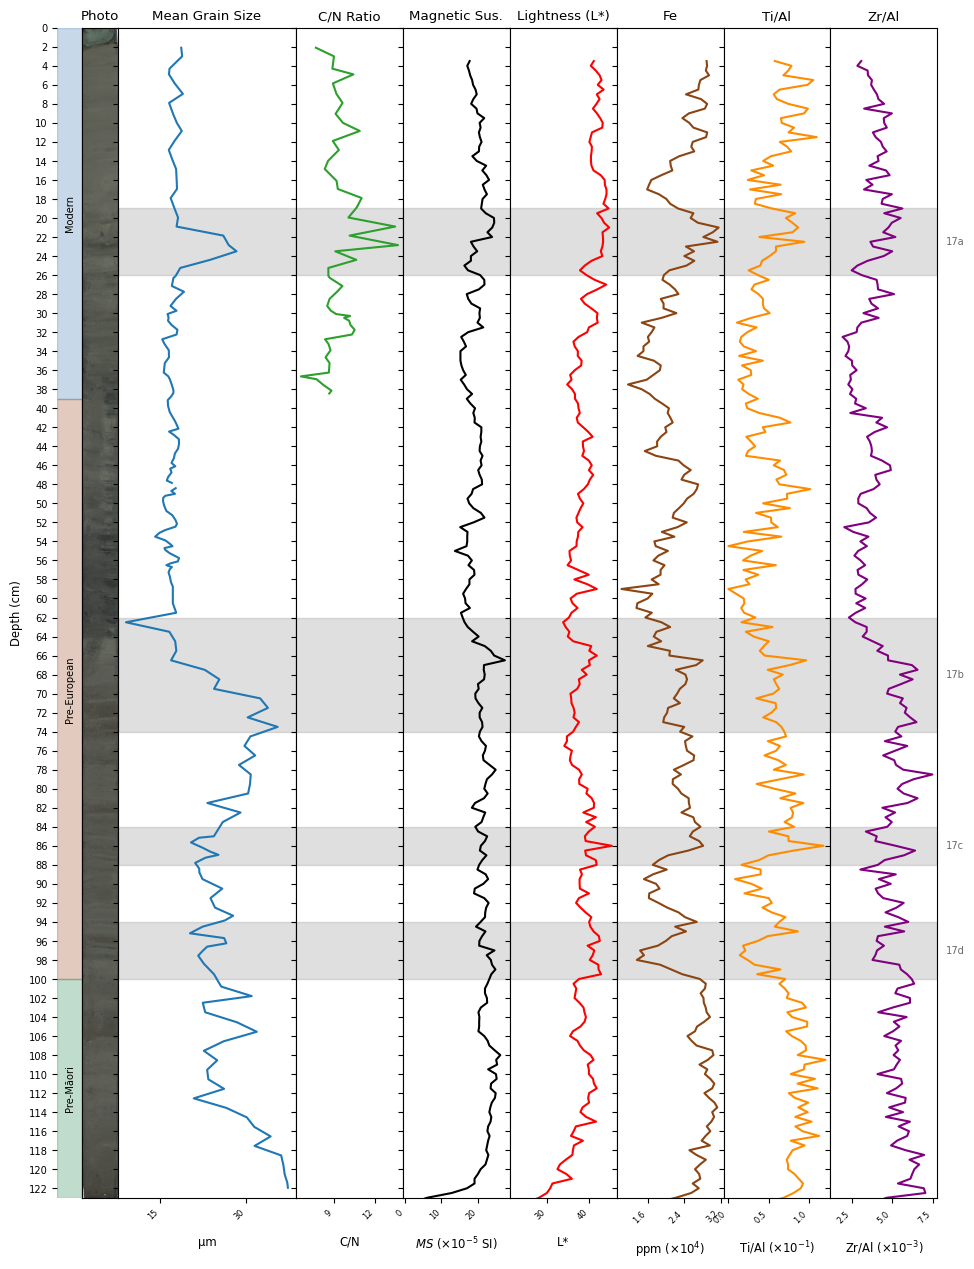

In [145]:
#Plot Core 17
physical_properties_17 = read_orca("Core Physical Properties/WAN1m17Mar26Pro.csv")
lab_results_17 = read_lab_results("Core Lab Results/W1M17_Lab_Data.csv")
events_17 = [
    ("17a", 19, 26),   # Example event deposit from 20-30 cm depth
    ("17b", 62, 74),
    ("17c", 84, 88),
    ("17d", 94, 100)
]
plot_core("W1M17","Core Images/WAN1m17Mar26.jpg", physical_properties_17, lab_results_17, 123, events_17)


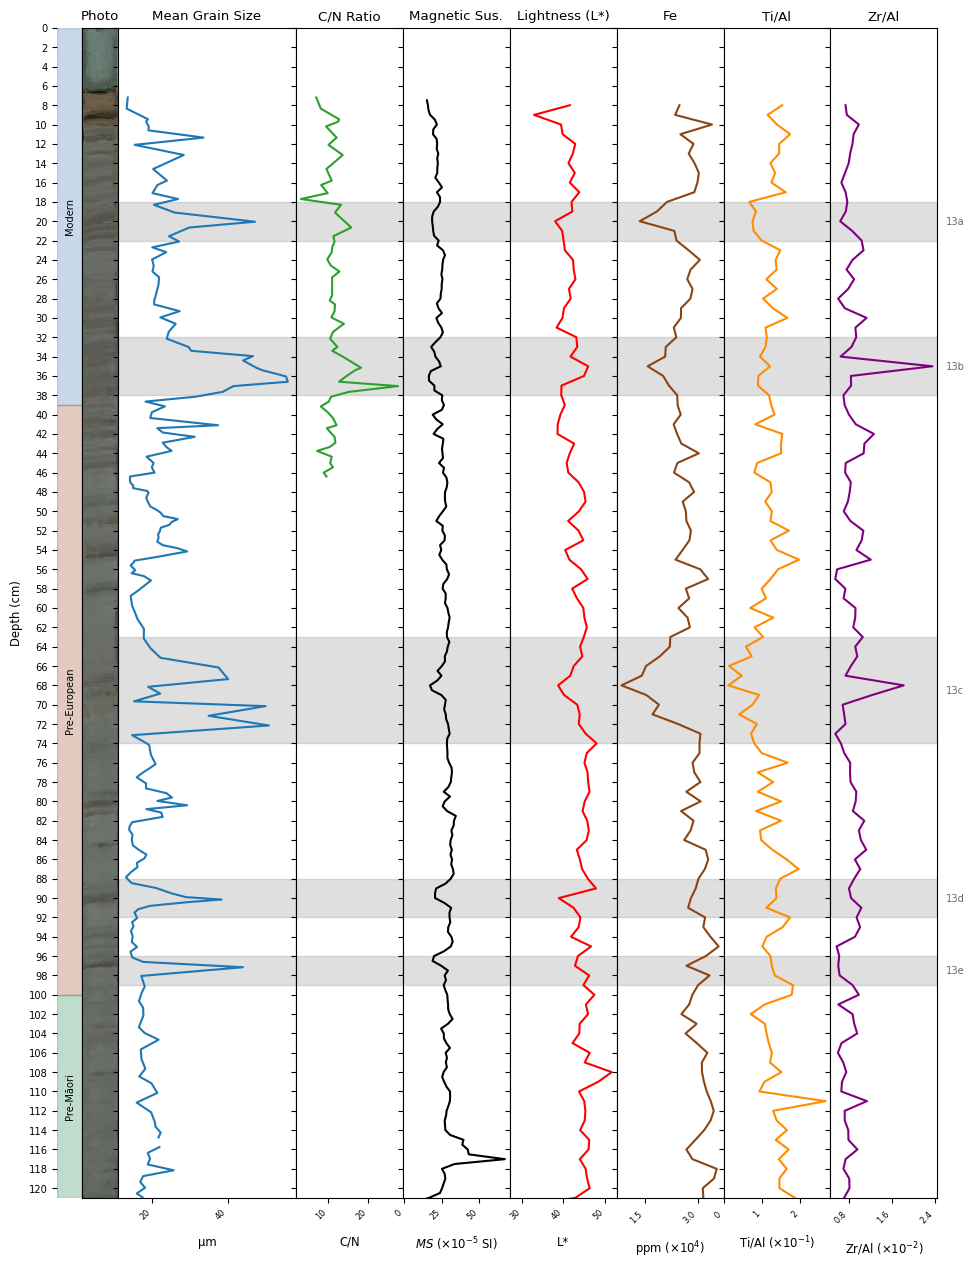

In [144]:

#Plot Core 13
physical_properties_13 = read_orca("Core Physical Properties/WAN1m13Mar26Pro.csv")
lab_results_13 = read_lab_results("Core Lab Results/W1M13_Lab_Data.csv")
events_13 = [
    ("13a", 18, 22),   # Example event deposit from 20-30 cm depth
    ("13b", 32, 38),
    ("13c", 63, 74),
    ("13d", 88, 92),
    ("13e", 96, 99)
]
plot_core("W1M13", "Core Images/WAN1m13Mar26.jpg", physical_properties_13, lab_results_13, 121, events_13)


In [152]:
def plot_core_comparison(
    properties_df_a, lab_results_df_a, depth_offset_a,
    properties_df_b, lab_results_df_b, depth_offset_b,
    label_a="Core 13", label_b="Core 17",
    max_depth=None, events=()
):
    """
    Compare two cores side by side on a shared adjusted depth axis.
    Depth is shown on the X axis; proxies on the Y axis.

    Parameters
    ----------
    properties_df_a/b  : DataFrame from read_orca() for each core
    lab_results_df_a/b : DataFrame from read_lab_results() for each core
    depth_offset_a/b   : float — depth (cm) of the top of the sediment in each
                         core (i.e. the floral foam thickness). This value is
                         subtracted so that 0 = top of sediment on the new axis.
    label_a/b          : str — legend labels for each core
    max_depth          : float — maximum adjusted depth to display, or None for auto
    events             : list of (label, min_depth_cm, max_depth_cm) tuples to shade
                         (depths are in adjusted coordinates)
    """

    # -----------------------------
    # Global style
    # -----------------------------
    FONT_SCALE = 0.8
    BASE = 14 * FONT_SCALE

    plt.rcParams.update({
        "font.size": BASE,
        "axes.titlesize": BASE * 1.15,
        "axes.labelsize": BASE,
        "xtick.labelsize": BASE * 0.85,
        "ytick.labelsize": BASE * 0.85,
    })

    COLOR_A = 'black'
    COLOR_B = 'red'
    lw = 1.5

    # -----------------------------
    # Helper — adjust depth and drop NaNs for a given pair of columns
    # -----------------------------
    def adjusted(df, depth_col, value_col, offset):
        sub = df[[depth_col, value_col]].dropna(subset=[value_col]).copy()
        sub[depth_col] = sub[depth_col] - offset
        return sub[depth_col], sub[value_col]

    # -----------------------------
    # Data — Core A (lab results)
    # -----------------------------
    depth_gs_a,  gs_a  = adjusted(lab_results_df_a, "Depth_Midpoint_cm", "Grain_Size_Mean",  depth_offset_a)
    depth_cn_a,  cn_a  = adjusted(lab_results_df_a, "Depth_Midpoint_cm", "CN_Ratio",         depth_offset_a)

    # Data — Core A (ORCA)
    depth_ms_a,  ms_a  = adjusted(properties_df_a,  "Depth_cm", "Magnetic_Susceptibility_x10_5_SI", depth_offset_a)
    depth_ls_a,  ls_a  = adjusted(properties_df_a,  "Depth_cm", "CIE_L_a_b_Colour_Space_L",         depth_offset_a)

    xrf_a = properties_df_a[["Depth_cm", "XRF_Elements_ppm_Fe_Value",
                               "XRF_Elements_ppm_Ti_Value", "XRF_Elements_ppm_Zr_Value",
                               "XRF_Elements_ppm_Al_Value"]].dropna().copy()
    xrf_a["Depth_cm"] -= depth_offset_a
    depth_xrf_a = xrf_a["Depth_cm"]
    fe_a        = xrf_a["XRF_Elements_ppm_Fe_Value"]
    ti_al_a     = xrf_a["XRF_Elements_ppm_Ti_Value"] / xrf_a["XRF_Elements_ppm_Al_Value"]
    zr_al_a     = xrf_a["XRF_Elements_ppm_Zr_Value"] / xrf_a["XRF_Elements_ppm_Al_Value"]

    # -----------------------------
    # Data — Core B (lab results)
    # -----------------------------
    depth_gs_b,  gs_b  = adjusted(lab_results_df_b, "Depth_Midpoint_cm", "Grain_Size_Mean",  depth_offset_b)
    depth_cn_b,  cn_b  = adjusted(lab_results_df_b, "Depth_Midpoint_cm", "CN_Ratio",         depth_offset_b)

    # Data — Core B (ORCA)
    depth_ms_b,  ms_b  = adjusted(properties_df_b,  "Depth_cm", "Magnetic_Susceptibility_x10_5_SI", depth_offset_b)
    depth_ls_b,  ls_b  = adjusted(properties_df_b,  "Depth_cm", "CIE_L_a_b_Colour_Space_L",         depth_offset_b)

    xrf_b = properties_df_b[["Depth_cm", "XRF_Elements_ppm_Fe_Value",
                               "XRF_Elements_ppm_Ti_Value", "XRF_Elements_ppm_Zr_Value",
                               "XRF_Elements_ppm_Al_Value"]].dropna().copy()
    xrf_b["Depth_cm"] -= depth_offset_b
    depth_xrf_b = xrf_b["Depth_cm"]
    fe_b        = xrf_b["XRF_Elements_ppm_Fe_Value"]
    ti_al_b     = xrf_b["XRF_Elements_ppm_Ti_Value"] / xrf_b["XRF_Elements_ppm_Al_Value"]
    zr_al_b     = xrf_b["XRF_Elements_ppm_Zr_Value"] / xrf_b["XRF_Elements_ppm_Al_Value"]

    # -----------------------------
    # Figure — 7 proxy panels, depth on x-axis
    # -----------------------------
    fig, axes = plt.subplots(
        7, 1,
        figsize=(12, 14),
        sharex=True
    )

    ax_gs, ax_cn, ax_ms, ax_ls, ax_fe, ax_ti, ax_zr = axes

    # -----------------------------
    # Proxy panels — both cores overlaid
    # -----------------------------
    ax_gs.plot(depth_gs_a, gs_a,  color=COLOR_A, linewidth=lw, label=label_a)
    ax_gs.plot(depth_gs_b, gs_b,  color=COLOR_B, linewidth=lw, label=label_b)
    ax_gs.set_ylabel("µm")
    ax_gs.set_title("Mean Grain Size")

    ax_cn.plot(depth_cn_a, cn_a,  color=COLOR_A, linewidth=lw)
    ax_cn.plot(depth_cn_b, cn_b,  color=COLOR_B, linewidth=lw)
    ax_cn.set_ylabel("C/N")
    ax_cn.set_title("C/N Ratio")

    ax_ms.plot(depth_ms_a, ms_a,  color=COLOR_A, linewidth=lw)
    ax_ms.plot(depth_ms_b, ms_b,  color=COLOR_B, linewidth=lw)
    ax_ms.set_ylabel(r"$\times 10^{-5}\ \mathrm{SI}$")
    ax_ms.set_title("Magnetic Sus.")

    ax_ls.plot(depth_ls_a, ls_a,  color=COLOR_A, linewidth=lw)
    ax_ls.plot(depth_ls_b, ls_b,  color=COLOR_B, linewidth=lw)
    ax_ls.set_ylabel("L*")
    ax_ls.set_title("Lightness (L*)")

    ax_fe.plot(depth_xrf_a, fe_a,    color=COLOR_A, linewidth=lw)
    ax_fe.plot(depth_xrf_b, fe_b,    color=COLOR_B, linewidth=lw)
    ax_fe.set_ylabel("ppm")
    ax_fe.set_title("Fe")

    ax_ti.plot(depth_xrf_a, ti_al_a, color=COLOR_A, linewidth=lw)
    ax_ti.plot(depth_xrf_b, ti_al_b, color=COLOR_B, linewidth=lw)
    ax_ti.set_ylabel("Ti/Al")
    ax_ti.set_title("Ti/Al")

    ax_zr.plot(depth_xrf_a, zr_al_a, color=COLOR_A, linewidth=lw)
    ax_zr.plot(depth_xrf_b, zr_al_b, color=COLOR_B, linewidth=lw)
    ax_zr.set_ylabel("Zr/Al")
    ax_zr.set_title("Zr/Al")
    ax_zr.set_xlabel("Depth (cm)")

    # -----------------------------
    # Event deposit shading
    # -----------------------------
    all_axes = list(axes)
    if events:
        for (event_label, d_min, d_max) in events:
            for ax in all_axes:
                ax.axvspan(d_min, d_max, color='grey', alpha=0.25, zorder=0)

            # Label above the top panel
            mid_depth = (d_min + d_max) / 2
            ax_gs.annotate(
                event_label,
                xy=(mid_depth, 1),
                xycoords=('data', 'axes fraction'),
                xytext=(0, 4),
                textcoords='offset points',
                va='bottom',
                ha='center',
                fontsize=BASE * 0.85,
                color='dimgrey',
                annotation_clip=False,
            )

    # -----------------------------
    # X axis limits
    # -----------------------------
    if max_depth is not None:
        ax_gs.set_xlim(0, max_depth)

    # -----------------------------
    # Legend — top panel only
    # -----------------------------
    ax_gs.legend(loc='upper right', fontsize=BASE)

    # -----------------------------
    # Layout
    # -----------------------------
    plt.tight_layout()
    plt.savefig("plots/core_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

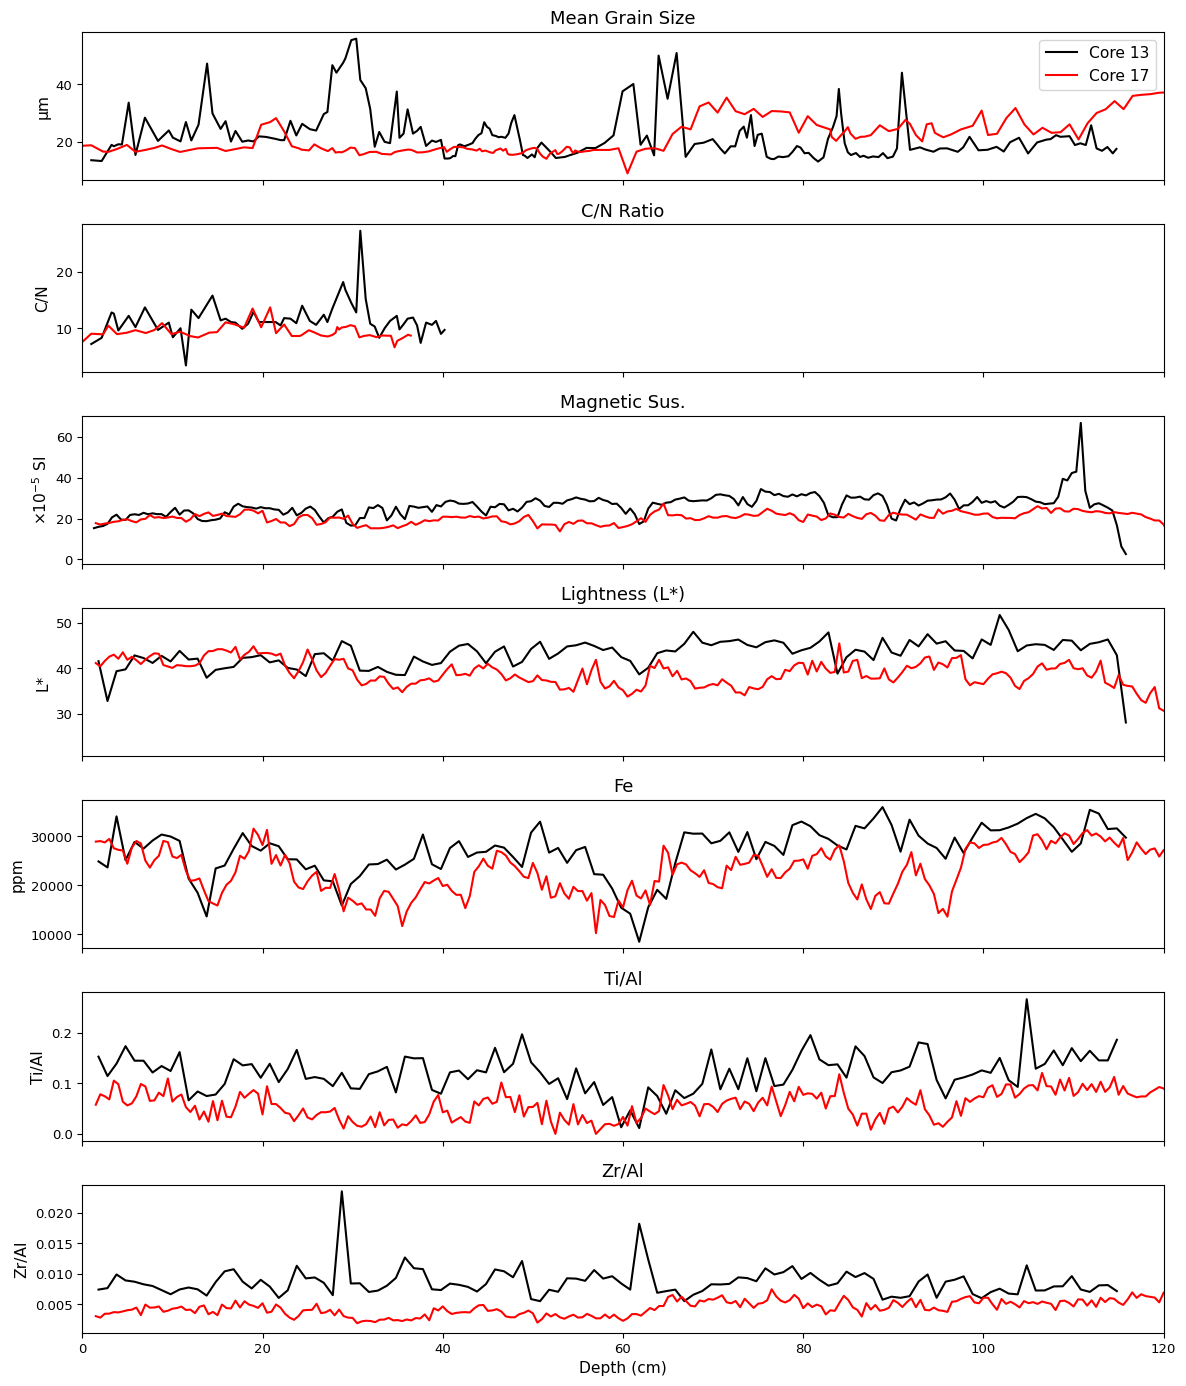

In [154]:
plot_core_comparison(
    physical_properties_13, lab_results_13, 6.2,
    physical_properties_17, lab_results_17, 2.0,
    label_a="Core 13",
    label_b="Core 17",
    max_depth=120,
    #events=[("E1", 20, 26), ("E2", 62, 74)]
)